# Buffer stock saving with HARK

The [model description](../../../models/buffer-stock/model-description.md) gives the theory and calibration. This example follows the [paper's HARK notebook](https://github.com/econ-ark/BufferStockTheory/blob/master/Code/Python/BufferStockTheory-Problems-and-Solutions-Source.ipynb), with the parameters and calculations below.

Install the packages listed in `requirements.txt`, then run all cells. The final cell saves optional comparison files in the working directory.

In [1]:
from pathlib import Path
from datetime import date
import platform

import HARK
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import yaml
from IPython.display import display
from HARK.ConsumptionSaving.ConsIndShockModel import IndShockConsumerType

## Set the parameters and solve

HARK's `CRRA` is the model's risk aversion parameter gamma. `IncUnemp=0` gives the zero-income event; `BoroCnstArt=None` retains only the natural borrowing limit.

In [2]:
parameters = {
    "PermGroFac": [1.03],
    "Rfree": [1.04],
    "DiscFac": 0.96,
    "CRRA": 2.0,
    "UnempPrb": 0.005,
    "IncUnemp": 0.0,
    "PermShkStd": [0.1],
    "TranShkStd": [0.1],
    "LivPrb": [1.0],
    "BoroCnstArt": None,
}

We use infinite-horizon endogenous grid iteration, linear interpolation and 960 asset points concentrated near zero. The stopping tolerance is 1e-6; accuracy is checked below.

In [3]:
agent = IndShockConsumerType(
    **parameters,
    cycles=0, T_cycle=1,
    PermShkCount=7, TranShkCount=7,
    aXtraCount=960, aXtraMin=0.001, aXtraMax=20.0, aXtraNestFac=3,
    CubicBool=False, vFuncBool=False, tolerance=1e-6,
)
agent.solve()
agent.check_conditions(verbose=False)
agent.calc_stable_points()
cfunc = agent.solution[0].cFunc
m_target = float(agent.solution[0].mNrmTrg)

## Check the shocks

Seven positive values per shock and the zero-income event give 56 joint outcomes. Calculate expectations from this distribution. Here `xi` includes zero income.

In [4]:
income = agent.IncShkDstn[0]
psi, xi = income.atoms
weights = income.pmv
G, R = parameters["PermGroFac"][0], parameters["Rfree"][0]
beta, gamma, wp = parameters["DiscFac"], parameters["CRRA"], parameters["UnempPrb"]
E_psi_inv = float(weights @ (psi ** -1))
E_psi_1mgamma = float(weights @ (psi ** (1 - gamma)))

assert np.isclose(weights.sum(), 1.0)
assert np.isclose(weights @ psi, 1.0)
assert np.isclose(weights @ xi, 1.0)
assert np.isclose(weights[xi == 0].sum(), wp)
print(f"{len(weights)} joint outcomes; both shock means are one.")

56 joint outcomes; both shock means are one.


## Plot consumption and expected resource growth

The zero crossing identifies the individual target, HARK's `mNrmTrg`. It differs from the balanced-growth pseudo-target `mNrmStE`.

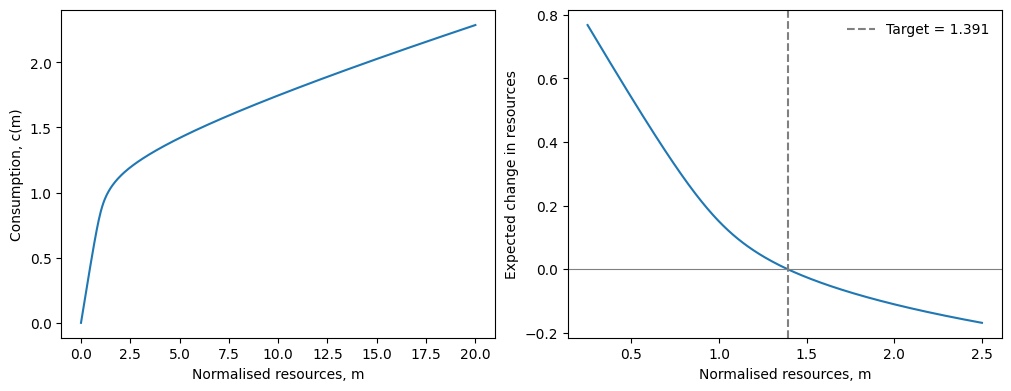

In [5]:
def resource_growth(m):
    return (m - cfunc(m)) * (R / G) * E_psi_inv + 1.0 - m

m_plot = np.linspace(0.0, 20.0, 600)
m_near_target = np.linspace(0.25, 2.5, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
axes[0].plot(m_plot, cfunc(m_plot))
axes[0].set(xlabel="Normalised resources, m", ylabel="Consumption, c(m)")
axes[1].plot(m_near_target, resource_growth(m_near_target))
axes[1].axhline(0, color="0.5", linewidth=0.8)
axes[1].axvline(m_target, color="0.5", linestyle="--", label=f"Target = {m_target:.3f}")
axes[1].set(xlabel="Normalised resources, m", ylabel="Expected change in resources")
axes[1].legend(frameon=False)
plt.show()

## Report the solution

Use the closed forms for limiting MPCs and a central difference with step 0.01 for the target MPC. These tables follow the [optional comparison conventions](../../../models/buffer-stock/README.md#optional-comparison-files). The CSV name `E_psi_1mrho` uses rho for gamma.

In [6]:
patience = (R * beta) ** (1 / gamma)
kappa_min = max(0.0, 1 - patience / R)
kappa_max = 1 - wp ** (1 / gamma) * patience / R
mpc_at_target = float((cfunc(m_target + 0.01) - cfunc(m_target - 0.01)) / 0.02)
m_grid = np.array([0.25, 0.5, 0.75, 1, 1.25, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 10, 15, 20])
consumption = pd.DataFrame({"m": m_grid, "c": cfunc(m_grid)})
scalars = pd.Series({
    "m_target": m_target, "mpc_at_target": mpc_at_target,
    "kappa_min": kappa_min, "kappa_max": kappa_max,
    "E_psi_inv": E_psi_inv, "E_psi_1mrho": E_psi_1mgamma,
}, name="value").rename_axis("name").reset_index()
display(consumption, scalars)

,m,c
0,0.25,0.232422
1,0.50,0.460669
2,0.75,0.675856
3,1.00,0.852785
4,1.25,0.964724
5,1.50,1.034645
6,2.00,1.127387
7,2.50,1.193952
8,3.00,1.248467
9,4.00,1.340116


,name,value
0,m_target,1.391031
1,mpc_at_target,0.269559
2,kappa_min,0.039231
3,kappa_max,0.932063
4,E_psi_inv,1.009383
5,E_psi_1mrho,1.009383


Each condition holds when its factor is below one. Factors use the same discretised shock moments as the solution.

In [7]:
conditions = pd.Series({
    "FVAC": beta * G ** (1 - gamma) * E_psi_1mgamma,
    "AIC": patience,
    "RIC": patience / R,
    "WRIC": wp ** (1 / gamma) * patience / R,
    "FHWC": G / R,
    "GIC": patience / G,
    "GICMod": patience / G * E_psi_inv,
}, name="factor").rename_axis("name").reset_index()
conditions["holds"] = conditions["factor"] < 1
conditions

,name,factor,holds
0,FVAC,0.940784,True
1,AIC,0.999200,True
2,RIC,0.960769,True
3,WRIC,0.067937,True
4,FHWC,0.990385,True
5,GIC,0.970097,True
6,GICMod,0.979199,True


## Check accuracy

Check feasibility, shape, the target equation and consumption-equivalent Euler errors. The optional [sensitivity study](checks/sensitivity.md) examines grid and shock refinement.

In [8]:
c_plot = np.asarray(cfunc(m_plot))
slopes = np.diff(c_plot) / np.diff(m_plot)
assert np.all((c_plot >= 0) & (c_plot <= m_plot))
assert np.all(slopes >= 0) and np.all(np.diff(slopes) <= 1e-9)
assert np.all(c_plot >= kappa_min * m_plot - 1e-9)
assert np.all(c_plot <= kappa_max * m_plot + 1e-9)
assert resource_growth(m_target - 0.5) > 0 > resource_growth(m_target + 0.5)
assert abs(resource_growth(m_target)) < 1e-9

c = np.asarray(cfunc(m_grid))
m_next = (m_grid - c)[:, None] * R / (G * psi) + xi
rhs = beta * R * np.sum(weights * (G * psi) ** (-gamma) * cfunc(m_next) ** (-gamma), axis=1)
euler_error = np.abs(rhs ** (-1 / gamma) / c - 1)
assert np.max(euler_error) < 1e-3
print(f"Maximum log10 relative consumption Euler error on the reporting grid: {np.log10(np.max(euler_error)):.2f}")

Maximum log10 relative consumption Euler error on the reporting grid: -4.23


## Save optional comparison files

This example writes the tables and software record below. Other projects can choose their own presentation and file format.

In [9]:
results = Path("results")
results.mkdir(exist_ok=True)
consumption.to_csv(results / "cfunc.csv", index=False)
scalars.to_csv(results / "scalars.csv", index=False)
conditions[["name", "holds"]].assign(
    holds=conditions["holds"].map({True: "true", False: "false"})
).to_csv(results / "conditions.csv", index=False)

metadata_path = Path("metadata.yml")
previous_metadata = (yaml.safe_load(metadata_path.read_text()) or {}) if metadata_path.exists() else {}
metadata = {
    "toolkit": "HARK", "toolkit_version": HARK.__version__,
    "authors": previous_metadata.get("authors", []),
    "model": "BST", "date": date.today().isoformat(),
    "template_version": "0.1",
    "template_source": "https://github.com/QuantEcon/community-library/tree/main/models/buffer-stock",
    "software": {
        "Python": platform.python_version(), "NumPy": np.__version__,
        "SciPy": scipy.__version__, "pandas": pd.__version__, "matplotlib": matplotlib.__version__,
    },
    "method": "Infinite-horizon endogenous grid iteration; linear consumption interpolation; tolerance 1e-6.",
    "discretisation": "Seven equiprobable positive values per income shock, plus zero income with probability 0.005; 56 joint outcomes.",
    "grid": "960 asset points from 0.001 to 20, HARK nesting factor 3.",
    "target_mpc": "Central difference with step 0.01.",
}
metadata_path.write_text(yaml.safe_dump(metadata, sort_keys=False), encoding="utf-8")
print("Saved three result tables and metadata.yml.")

Saved three result tables and metadata.yml.
